<a href="https://colab.research.google.com/github/lucasvazelle/nexialog_challlenge/blob/main/etape4_model_ML_NS_DBSCAN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
! pip install ace-tools

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# from scipy.stats import genpareto


In [5]:
# chemin
file_path = "/content/drive/MyDrive/nexialog/data_agrege_S3.parquet"

# Lire le fichier Parquet
data_agrege_S3 = pd.read_parquet(file_path)


In [6]:
data_agrege_S3.columns

Index(['olt_name', 'date_hour', 'code_departement', 'olt_model', 'peag_nro',
       'boucle', 'dsp', 'pop_dns', 'nb_test_dns', 'avg_dns_time',
       'std_dns_time', 'nb_test_scoring', 'avg_latence_scoring',
       'std_latence_scoring', 'avg_score_scoring', 'std_score_scoring',
       'nb_client_total', 'moment_journee', 'depts_egaux', 'meme_region',
       'missing_avg_dns_time', 'missing_std_dns_time',
       'missing_avg_latence_scoring', 'missing_std_latence_scoring',
       'missing_avg_score_scoring', 'missing_std_score_scoring', 'type_boucle',
       'type_olt_model', 'encodage_heure_sin', 'encodage_heure_cos',
       'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos', 'week_end'],
      dtype='object')

In [7]:
data_agrege_S3.head()

,olt_name,date_hour,code_departement,olt_model,peag_nro,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,missing_std_latence_scoring,missing_avg_score_scoring,missing_std_score_scoring,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end
0,01_olt_1,2024-12-01 00:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,61,4.888439,...,0,0,0,BU,old,0.000000,1.000000,-0.781831,0.62349,True
1,01_olt_1,2024-12-01 01:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,58,5.293034,...,0,0,0,BU,old,0.258819,0.965926,-0.781831,0.62349,True
2,01_olt_1,2024-12-01 02:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,67,5.103739,...,0,0,0,BU,old,0.500000,0.866025,-0.781831,0.62349,True
3,01_olt_1,2024-12-01 03:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,40,5.342719,...,0,0,0,BU,old,0.707107,0.707107,-0.781831,0.62349,True
4,01_olt_1,2024-12-01 04:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,50,4.997415,...,0,0,0,BU,old,0.866025,0.500000,-0.781831,0.62349,True


In [8]:
data_agrege_S3.isna().sum()

,0
olt_name,0
date_hour,0
code_departement,0
olt_model,0
peag_nro,0
boucle,0
dsp,0
pop_dns,0
nb_test_dns,0
avg_dns_time,2710


### Quelques exemples

paramètre eps définit la distance maximale entre deux points pour qu'ils soient considérés comme voisins, et min_samples définit le nombre minimum de voisins requis pour qu'un point soit considéré comme faisant partie d'un cluster

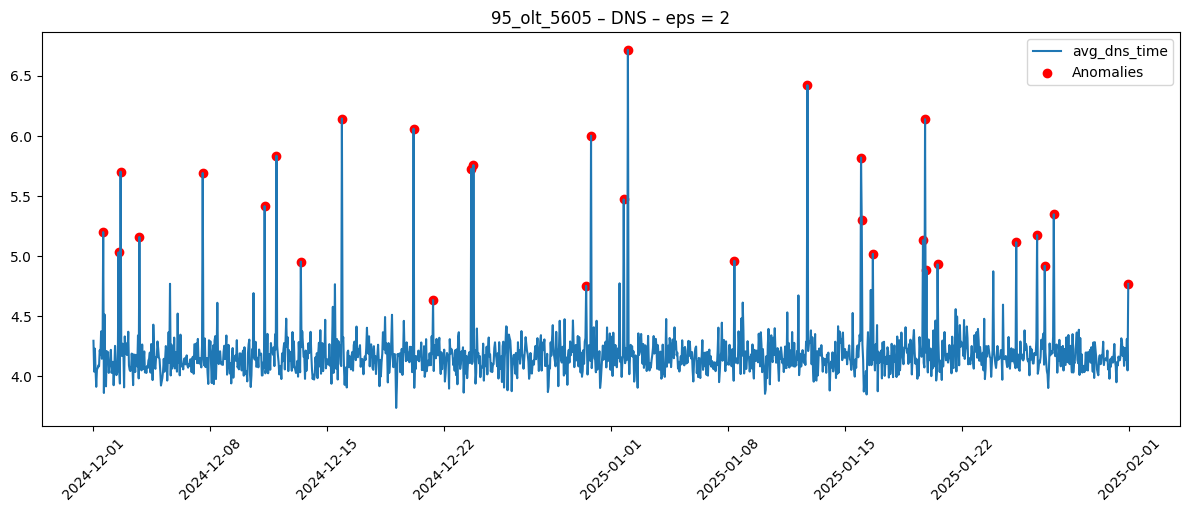

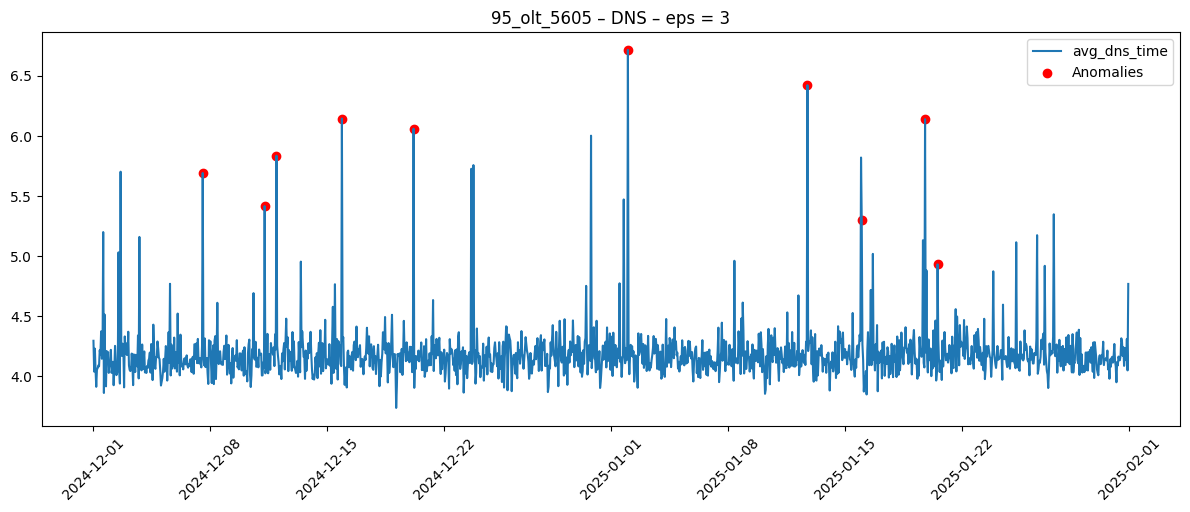

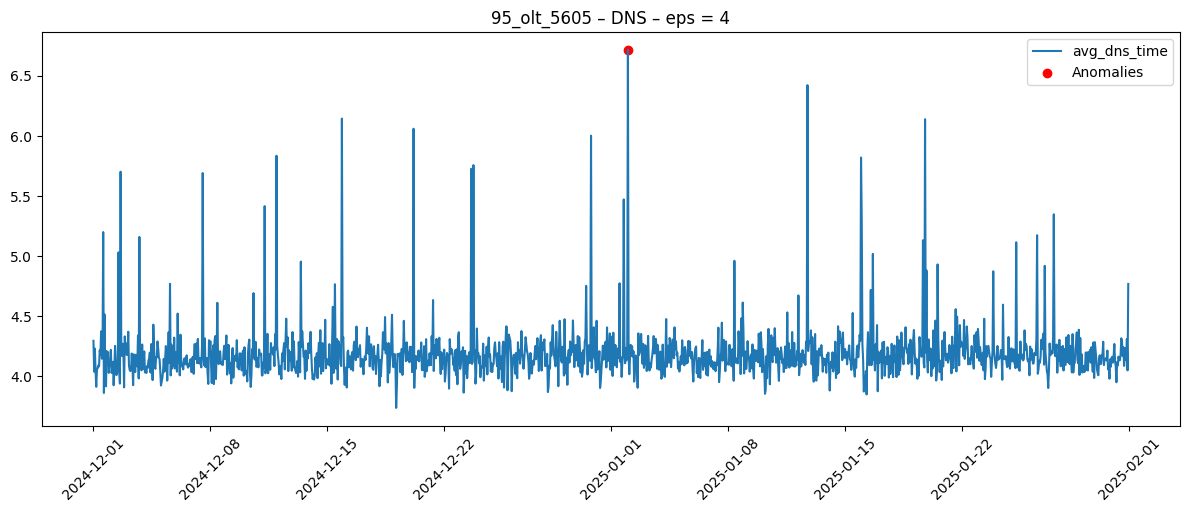

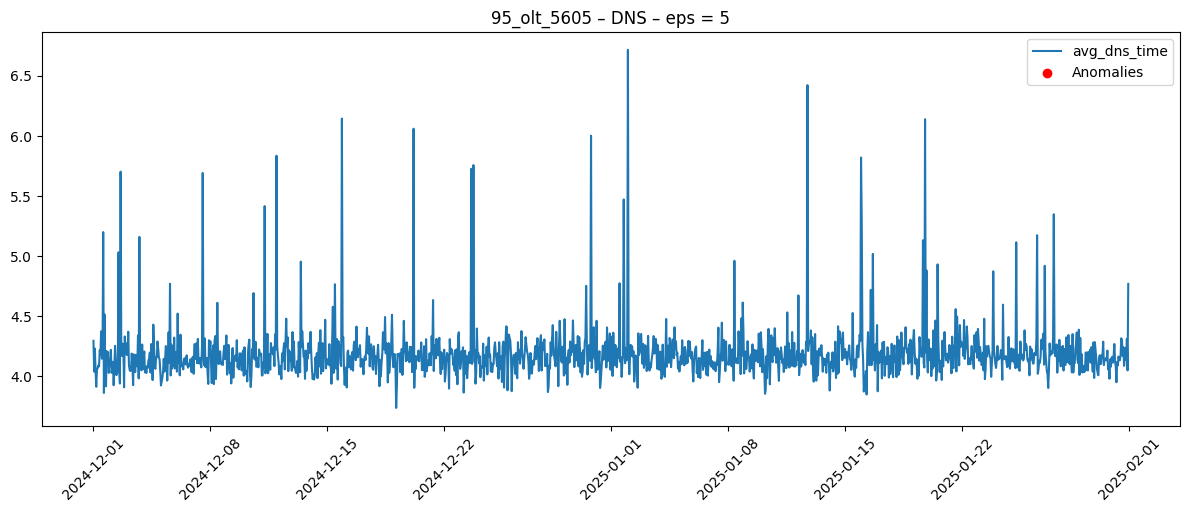

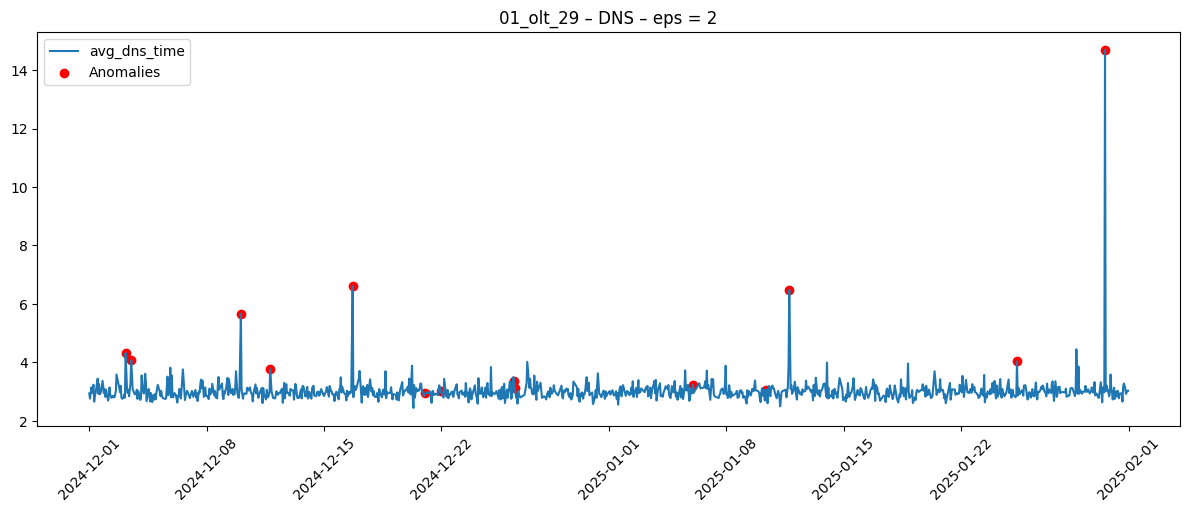

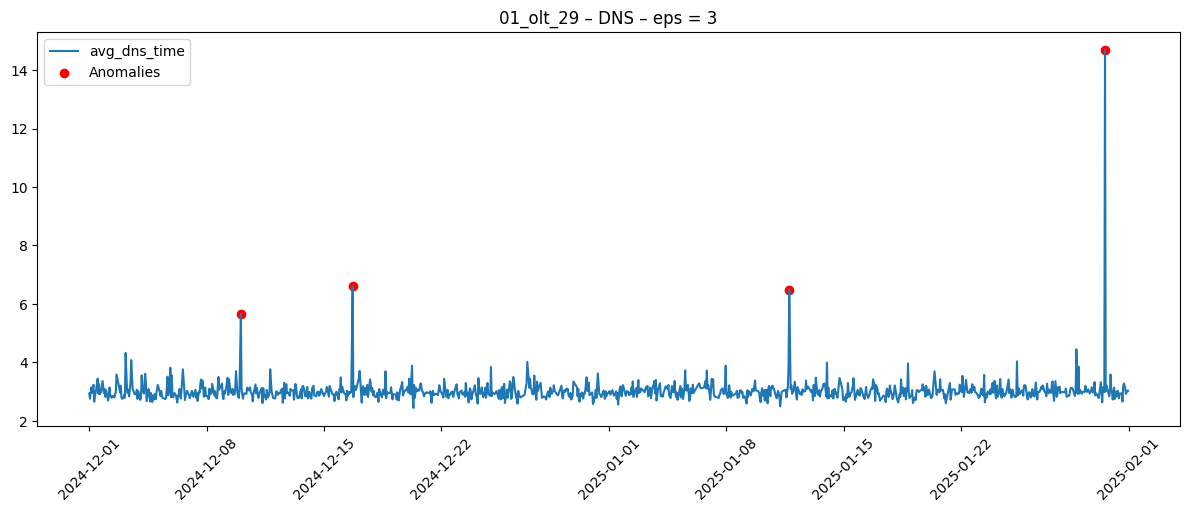

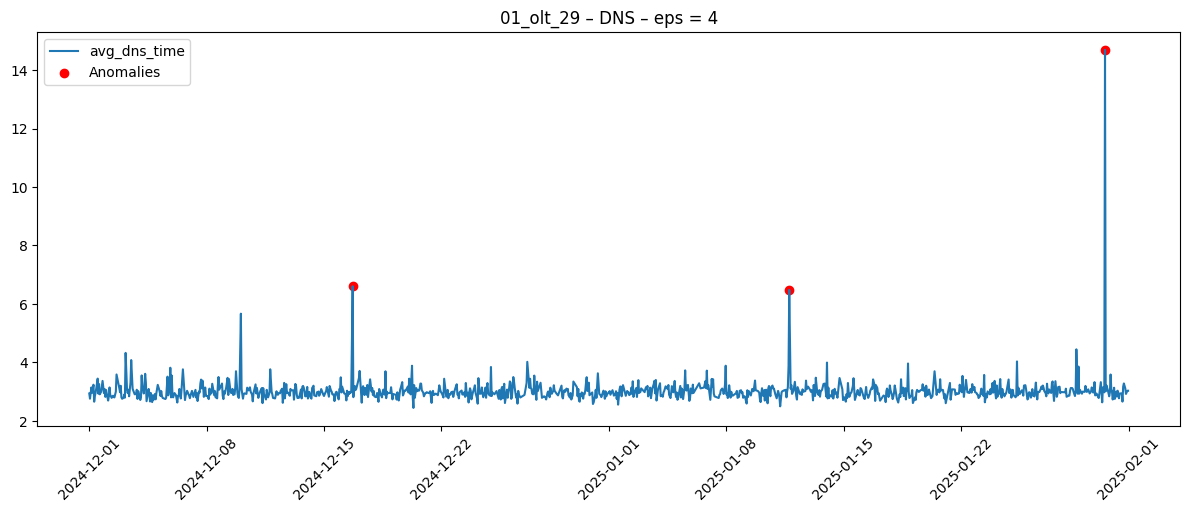

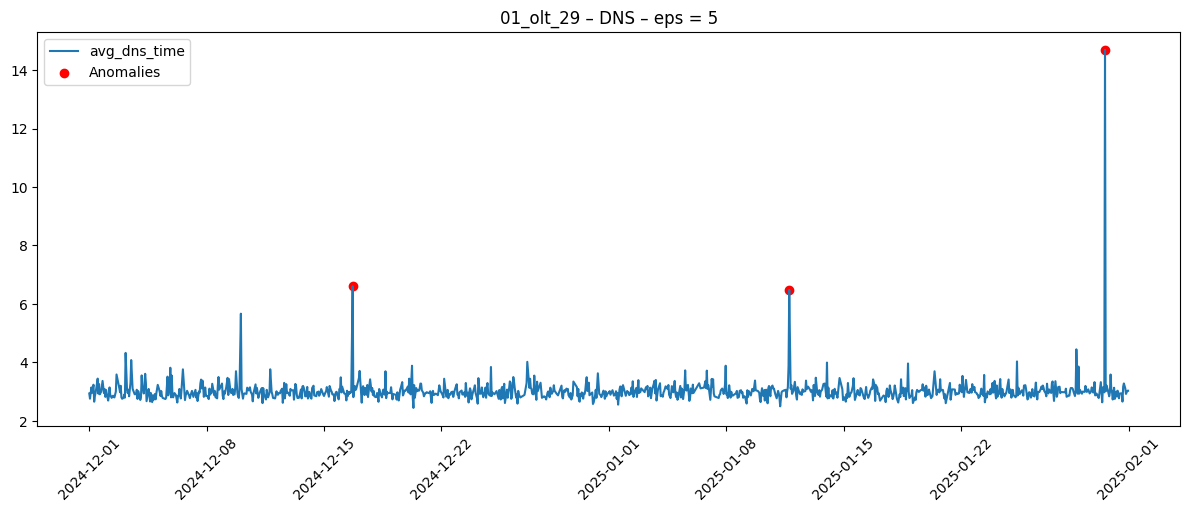

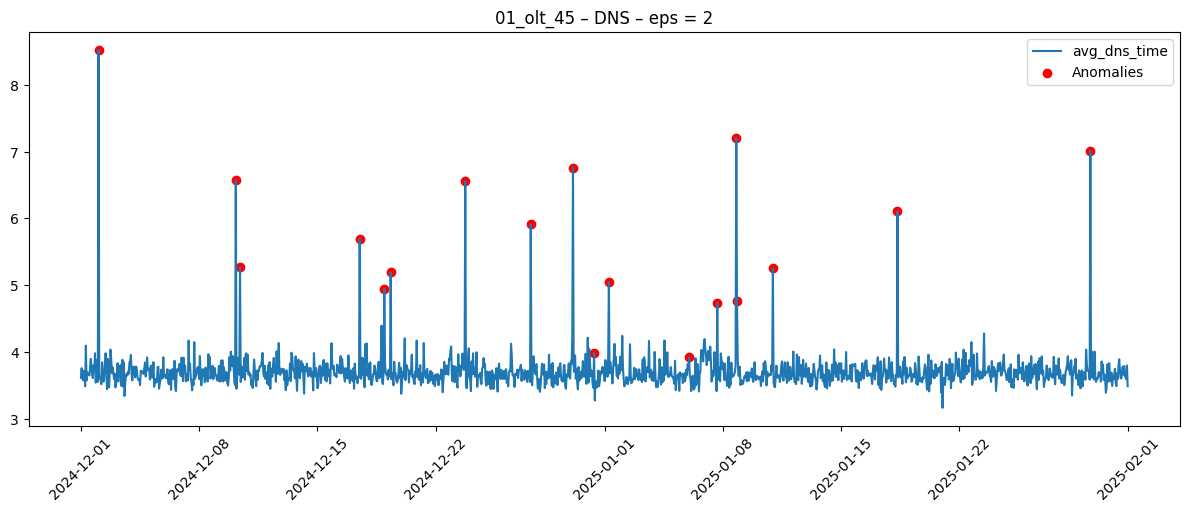

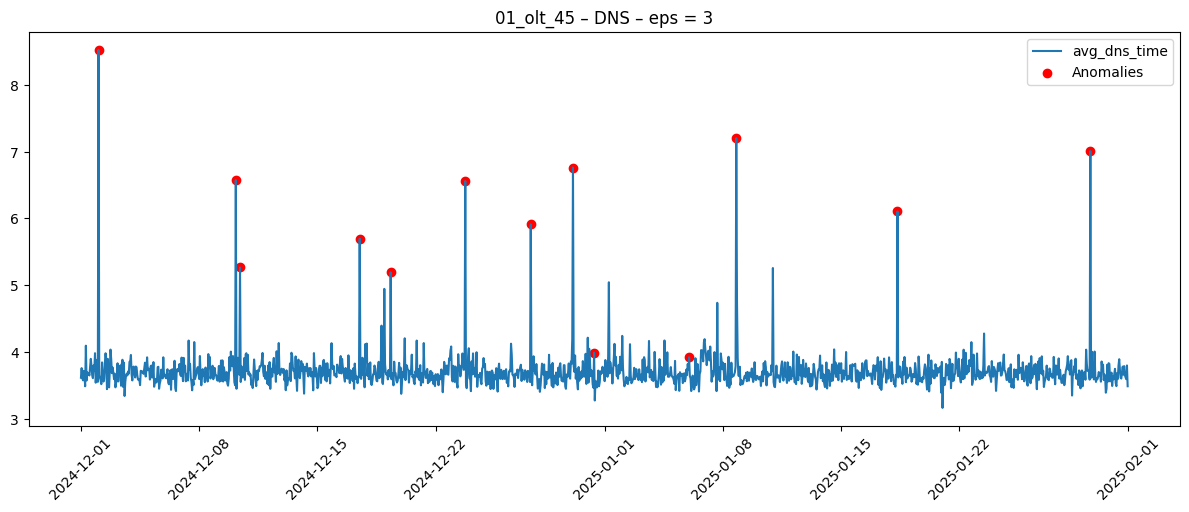

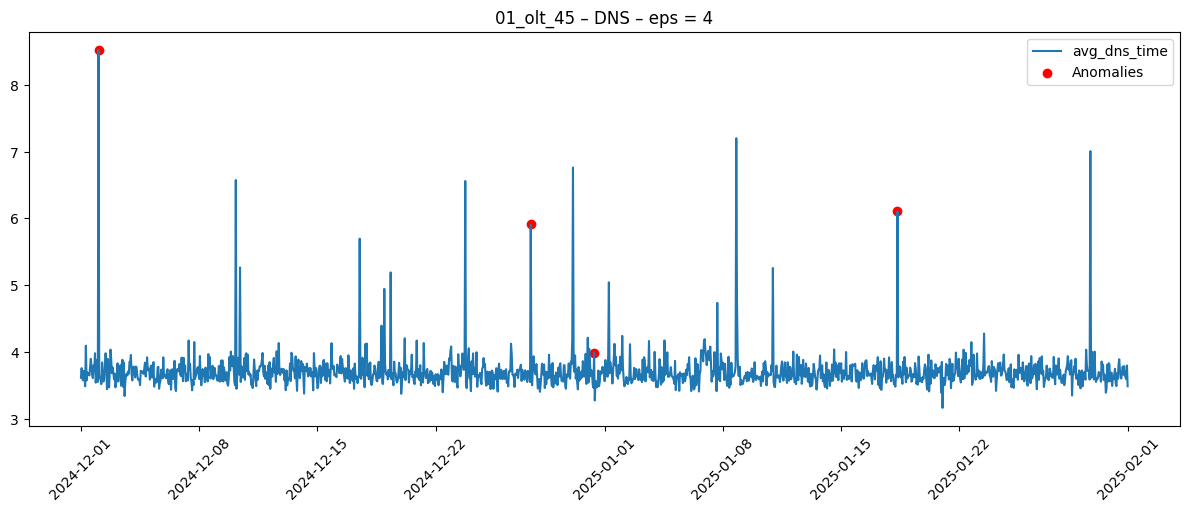

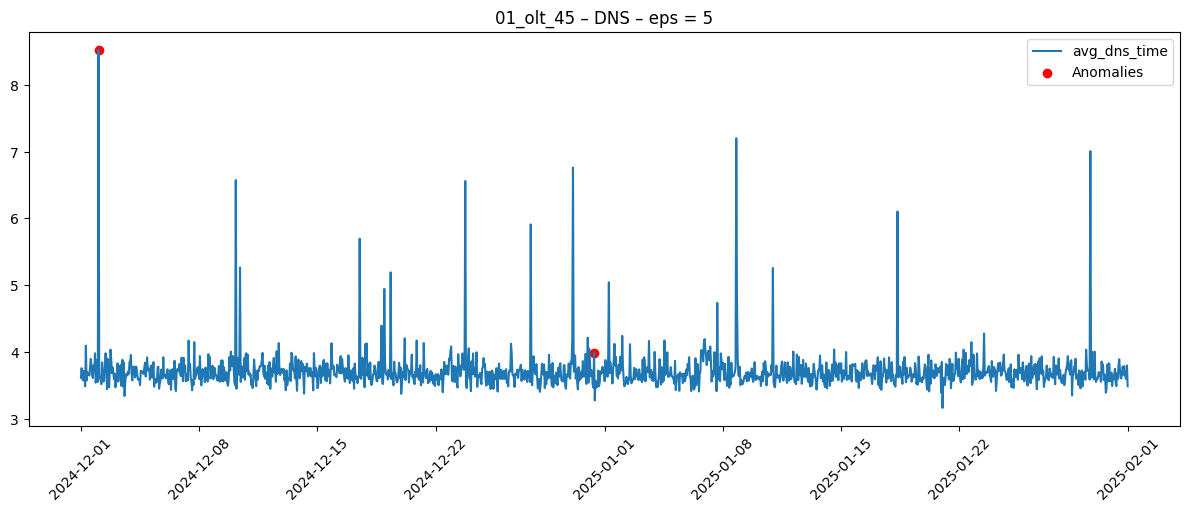

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def detect_anomalies_dbscan(df, test_type='dns', eps=4, min_samples=5):
    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    else:
        raise ValueError("test_type doit être 'dns' ou 'scoring'")

    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    features = required_cols + time_features
    df_clean = df[features + ['date_hour']].dropna().copy()

    if df_clean.empty:
        return None

    X_scaled = StandardScaler().fit_transform(df_clean[features])
    db = DBSCAN(eps=eps, min_samples=min_samples)
    df_clean[prefix] = db.fit_predict(X_scaled)

    return df_clean

# Liste des OLTs et des valeurs de eps à tester
olts = ["95_olt_5605", "01_olt_29", "01_olt_45"]
eps_values = [2, 3, 4, 5]
test_type = 'dns'

# Boucle principale
for olt in olts:
    df_olt = data_agrege_S3[data_agrege_S3['olt_name'] == olt]

    for eps in eps_values:
        df_anomalies = detect_anomalies_dbscan(df_olt, test_type=test_type, eps=eps, min_samples=5)

        if df_anomalies is not None:
            anomaly_col = f"anomaly_{test_type}"
            test_col = 'avg_dns_time' if test_type == 'dns' else 'avg_score_scoring'

            plt.figure(figsize=(12, 5))
            plt.plot(df_anomalies['date_hour'], df_anomalies[test_col], label=test_col)
            plt.scatter(
                df_anomalies['date_hour'][df_anomalies[anomaly_col] == -1],
                df_anomalies[test_col][df_anomalies[anomaly_col] == -1],
                color='red', label='Anomalies'
            )
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.title(f"{olt} – {test_type.upper()} – eps = {eps}")
            plt.show()
        else:
            print(f"[{olt}] Aucune donnée exploitable pour eps={eps}")

### pour les tests dns le meilleur epsilon est de 3 (detection des pics)

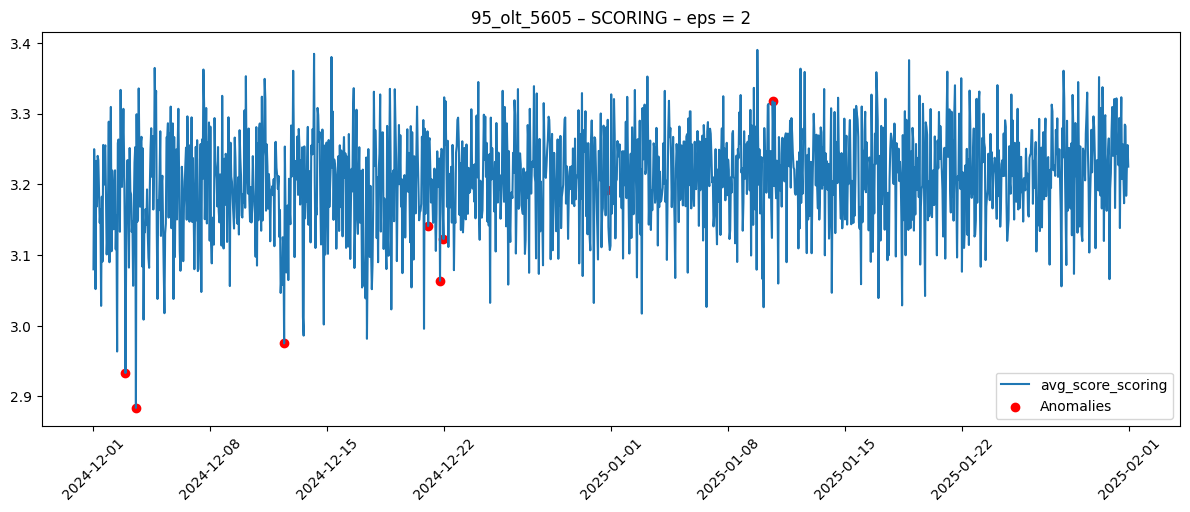

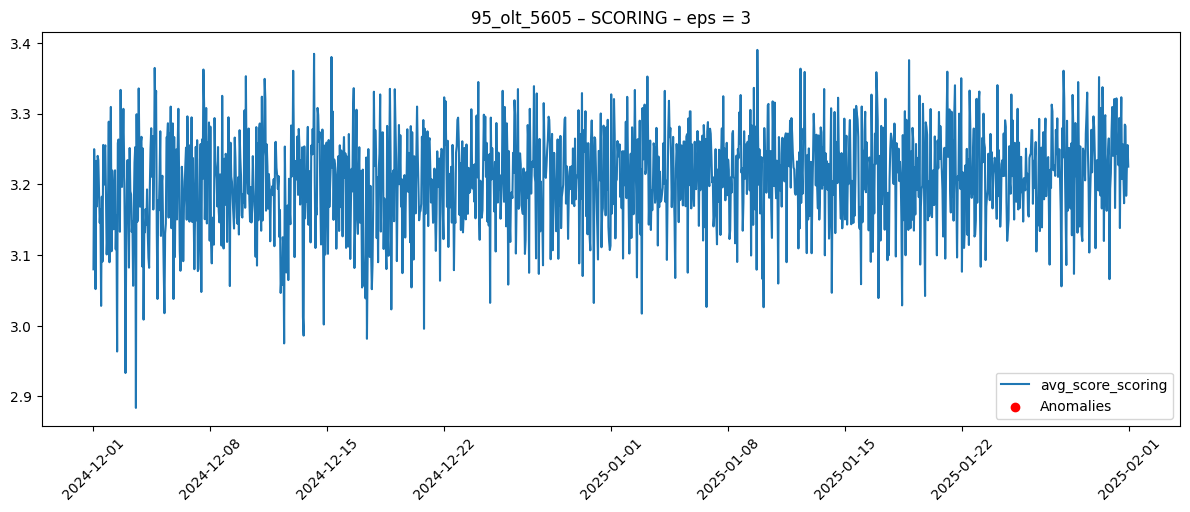

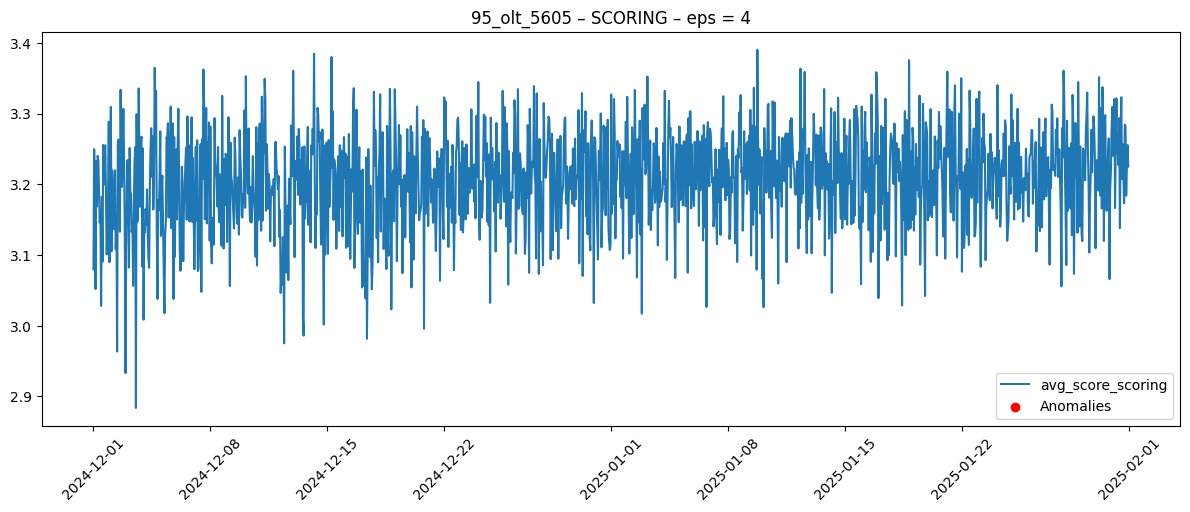

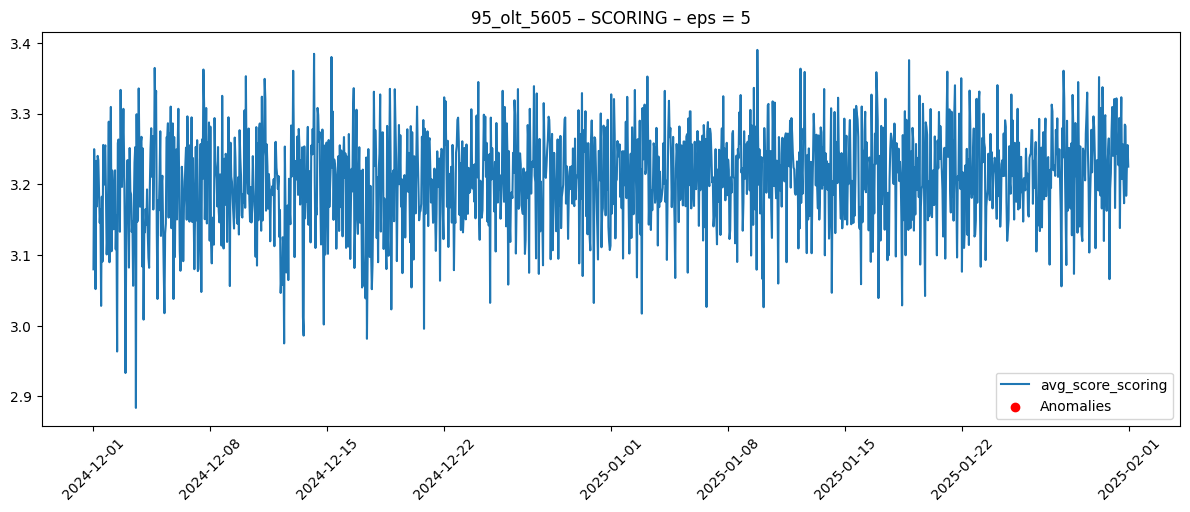

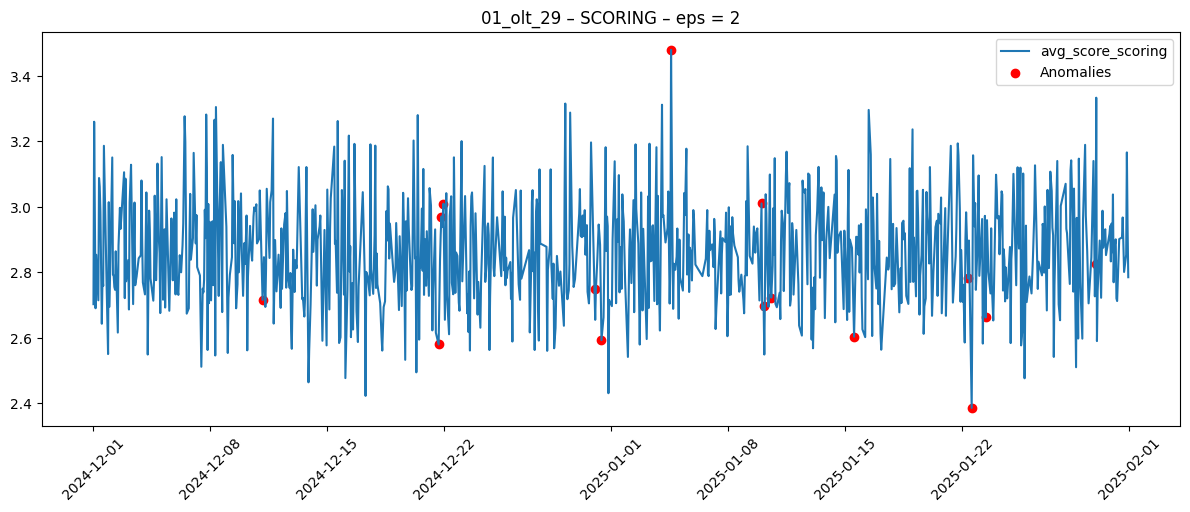

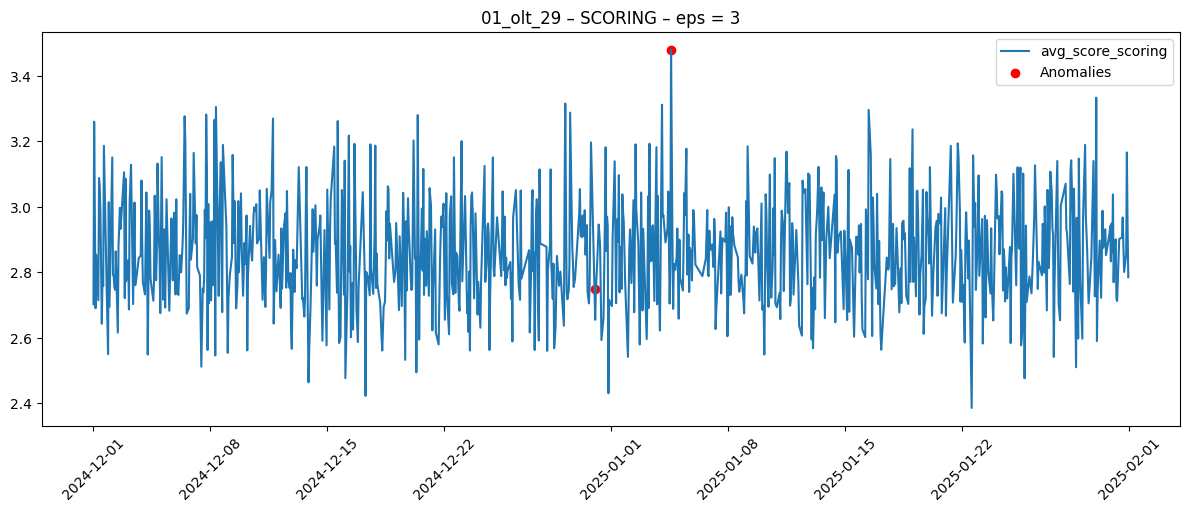

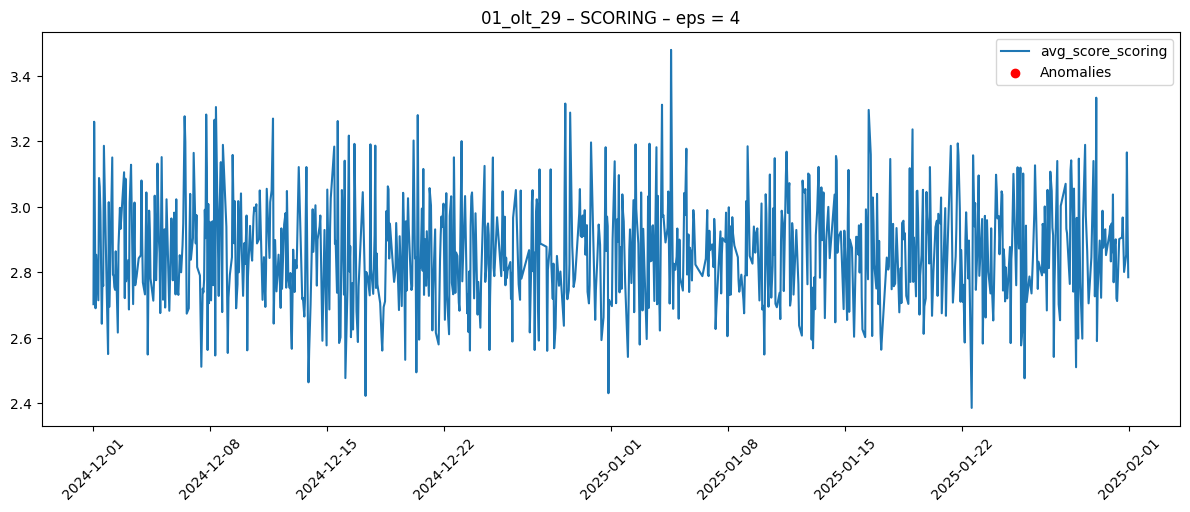

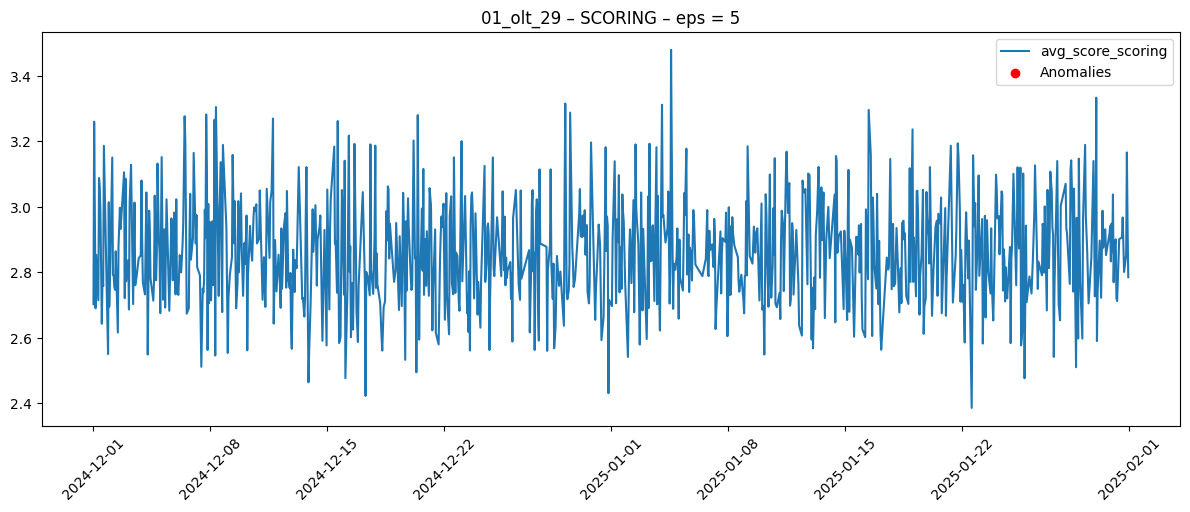

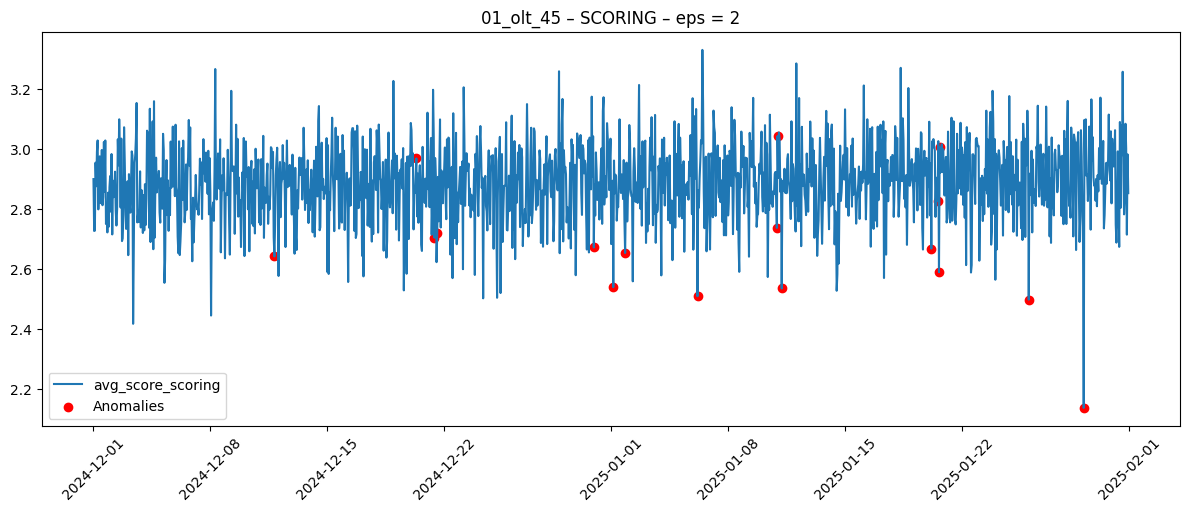

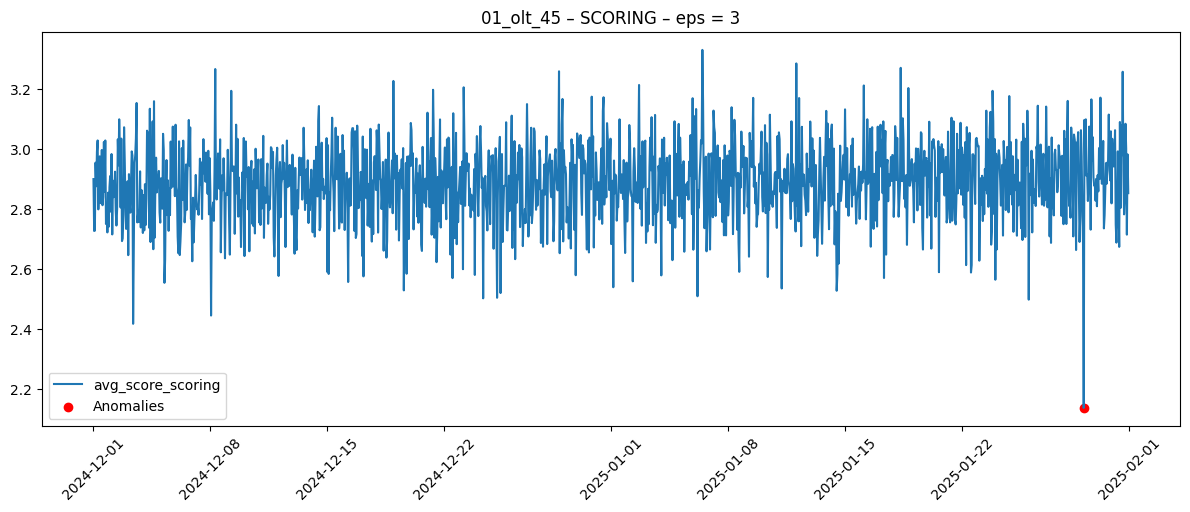

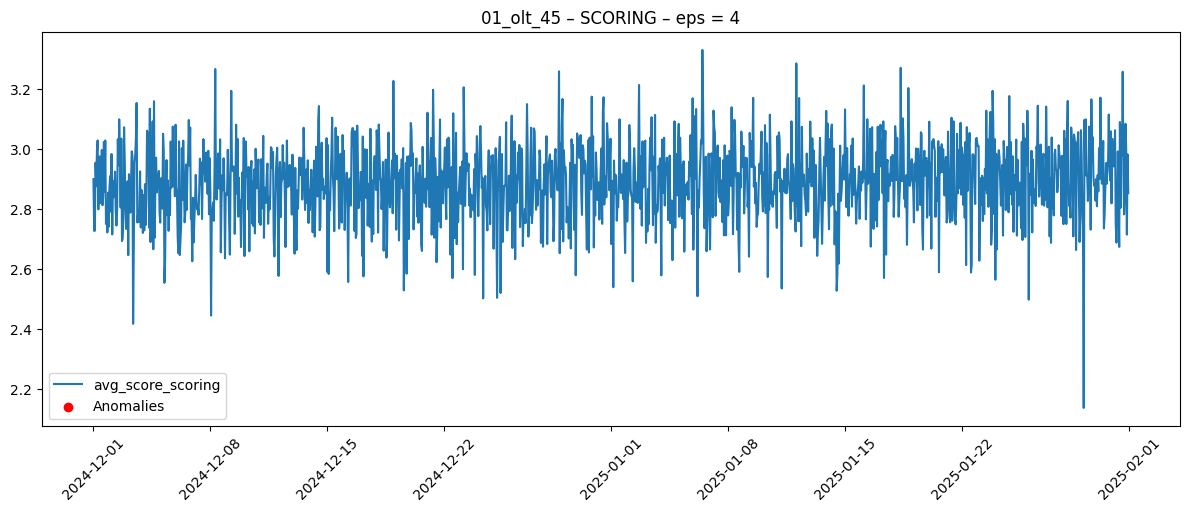

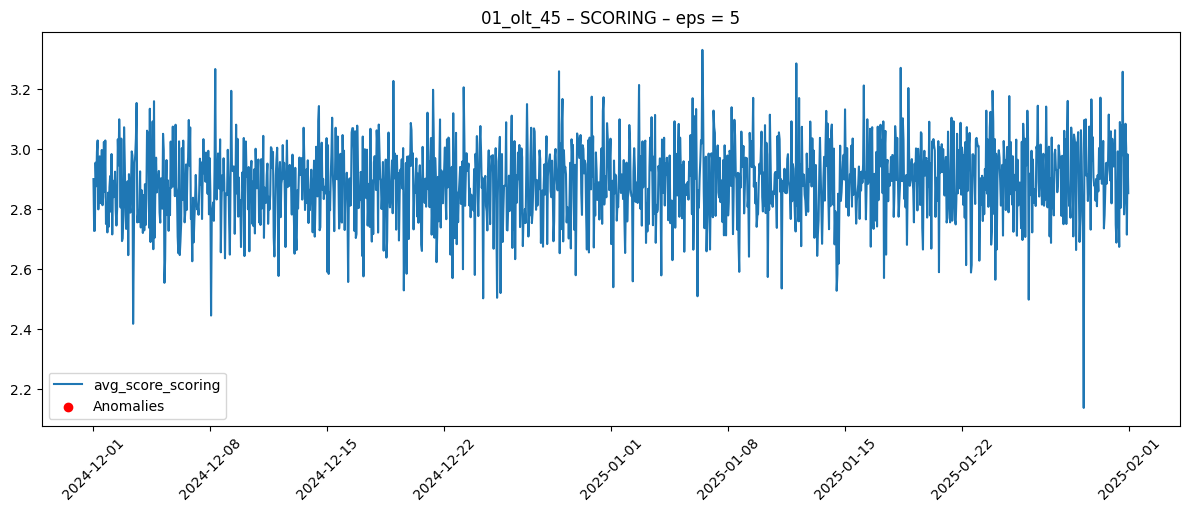

In [10]:
test_type = 'scoring'

for olt in olts:
    df_olt = data_agrege_S3[data_agrege_S3['olt_name'] == olt]

    for eps in eps_values:
        df_anomalies = detect_anomalies_dbscan(df_olt, test_type=test_type, eps=eps, min_samples=5)

        if df_anomalies is not None:
            anomaly_col = f"anomaly_{test_type}"
            test_col = 'avg_score_scoring'

            plt.figure(figsize=(12, 5))
            plt.plot(df_anomalies['date_hour'], df_anomalies[test_col], label=test_col)
            plt.scatter(
                df_anomalies['date_hour'][df_anomalies[anomaly_col] == -1],
                df_anomalies[test_col][df_anomalies[anomaly_col] == -1],
                color='red', label='Anomalies'
            )
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.title(f"{olt} – {test_type.upper()} – eps = {eps}")
            plt.show()
        else:
            print(f"[{olt}] Aucune donnée exploitable pour eps={eps}")

### pour les tests scoring le meilleur epsilon est de 3 (detection des pics)

### fonctions

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def detect_anomalies_dbscan(df, test_type='dns', eps=3, min_samples=4):
    """
    Détecte les anomalies avec DBSCAN

    Args:
        df: DataFrame avec les données
        test_type: 'dns', 'scoring' ou 'latence'
        eps: Paramètre eps pour DBSCAN
        min_samples: Paramètre min_samples pour DBSCAN

    Returns:
        DataFrame avec les prédictions d'anomalies
    """

    if test_type == 'dns':
        required_cols = ['nb_test_dns', 'avg_dns_time', 'std_dns_time']
        prefix = 'anomaly_dns'
    elif test_type == 'scoring':
        required_cols = ['nb_test_scoring', 'avg_score_scoring', 'std_score_scoring']
        prefix = 'anomaly_scoring'
    elif test_type == 'latence':
        required_cols = ['nb_test_scoring', 'avg_latence_scoring', 'std_latence_scoring']
        prefix = 'anomaly_latence'
    else:
        raise ValueError("test_type doit être 'dns', 'scoring' ou 'latence'")

    # Ajouter les caractéristiques temporelles
    time_features = [
        'encodage_heure_sin', 'encodage_heure_cos',
        'encodage_jour_semaine_sin', 'encodage_jour_semaine_cos',
        'week_end'
    ]

    # Combiner les features
    features = required_cols + time_features

    existing_features = [col for col in features if col in df.columns]

    # Nettoyer les données
    df_clean = df[existing_features + ['date_hour']].dropna().copy()

    if df_clean.empty:
        return None

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[existing_features])

    # Appliquer DBSCAN
    model = DBSCAN(eps=eps, min_samples=min_samples)
    df_clean[prefix] = model.fit_predict(X_scaled)

    return df_clean

Nombre total de points DNS: 1488
Nombre d'anomalies DNS: 17 (1.14%)


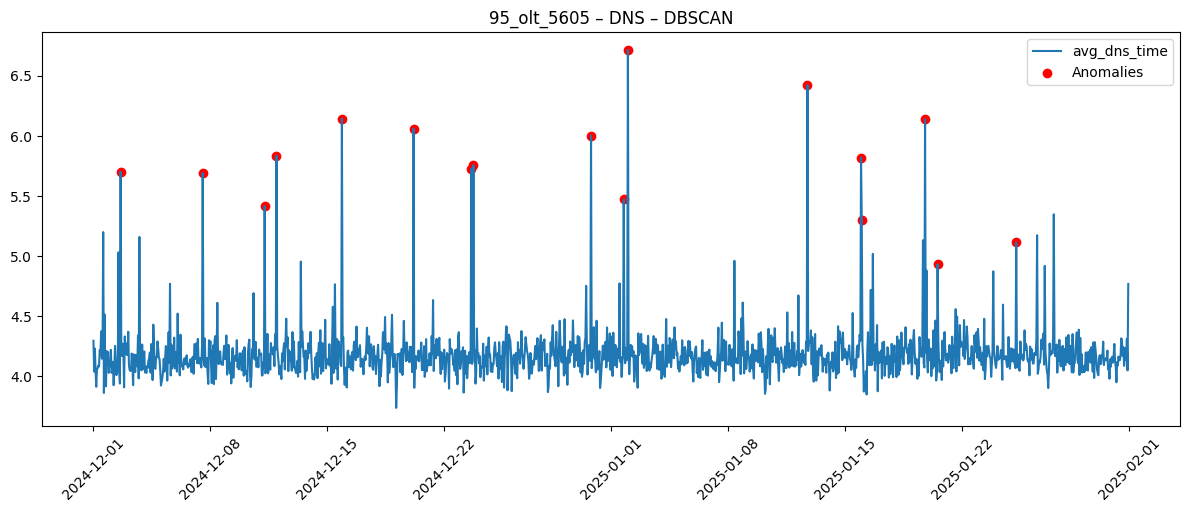

Nombre total de points Latence: 1488
Nombre d'anomalies Latence: 8 (0.54%)


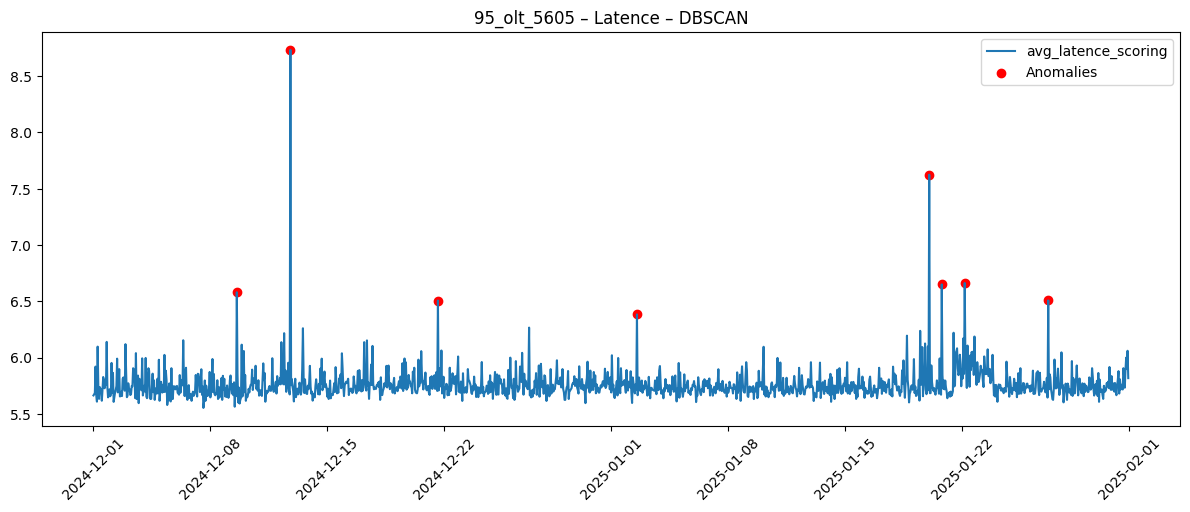

In [13]:
# Choisir un OLT
olt_test = "95_olt_5605"  # Remplacez par un de vos OLTs
df_olt = data_agrege_S3[data_agrege_S3['olt_name'] == olt_test]

# Appliquer DBSCAN pour le DNS
df_anomalies_dns = detect_anomalies_dbscan(df_olt, test_type='dns', eps=3, min_samples=8)

# Vérifier les résultats DNS
if df_anomalies_dns is not None:
    # Compter les anomalies
    anomaly_col = 'anomaly_dns'
    anomaly_count = sum(df_anomalies_dns[anomaly_col] == -1)
    print(f"Nombre total de points DNS: {len(df_anomalies_dns)}")
    print(f"Nombre d'anomalies DNS: {anomaly_count} ({anomaly_count/len(df_anomalies_dns)*100:.2f}%)")

    # Visualiser
    plt.figure(figsize=(12, 5))
    plt.plot(df_anomalies_dns['date_hour'], df_anomalies_dns['avg_dns_time'], label='avg_dns_time')
    plt.scatter(
        df_anomalies_dns['date_hour'][df_anomalies_dns[anomaly_col] == -1],
        df_anomalies_dns['avg_dns_time'][df_anomalies_dns[anomaly_col] == -1],
        color='red', label='Anomalies'
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{olt_test} – DNS – DBSCAN")
    plt.show()
else:
    print("Aucune donnée DNS exploitable")

# Appliquer DBSCAN pour la Latence
df_anomalies_latence = detect_anomalies_dbscan(df_olt, test_type='latence', eps=3, min_samples=8)

# Vérifier les résultats Latence
if df_anomalies_latence is not None:
    # Compter les anomalies
    anomaly_col = 'anomaly_latence'
    anomaly_count = sum(df_anomalies_latence[anomaly_col] == -1)
    print(f"Nombre total de points Latence: {len(df_anomalies_latence)}")
    print(f"Nombre d'anomalies Latence: {anomaly_count} ({anomaly_count/len(df_anomalies_latence)*100:.2f}%)")

    # Visualiser
    plt.figure(figsize=(12, 5))
    plt.plot(df_anomalies_latence['date_hour'], df_anomalies_latence['avg_latence_scoring'], label='avg_latence_scoring')
    plt.scatter(
        df_anomalies_latence['date_hour'][df_anomalies_latence[anomaly_col] == -1],
        df_anomalies_latence['avg_latence_scoring'][df_anomalies_latence[anomaly_col] == -1],
        color='red', label='Anomalies'
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{olt_test} – Latence – DBSCAN")
    plt.show()
else:
    print("Aucune donnée Latence exploitable")

In [14]:
def add_dbscan_anomaly_columns(df, test_types=['dns', 'scoring', 'latence']):
    """
    Ajoute des colonnes indiquant si chaque point est une anomalie selon DBSCAN

    Args:
        df: DataFrame complet
        test_types: Types de tests à analyser

    Returns:
        DataFrame avec colonnes d'anomalies ajoutées
    """
    df_result = df.copy()

    # Créer les colonnes d'anomalies au début avec False par défaut
    for test_type in test_types:
        flag_col = f'is_anomaly_{test_type}'
        df_result[flag_col] = False

    # Pour chaque OLT
    for olt in df['olt_name'].unique():
        print(f"Traitement de l'OLT: {olt}")
        df_olt = df[df['olt_name'] == olt]

        for test_type in test_types:
            print(f"  Type de test: {test_type}")
            flag_col = f'is_anomaly_{test_type}'

            # Appliquer DBSCAN
            df_anomalies = detect_anomalies_dbscan(df_olt, test_type=test_type)

            if df_anomalies is not None:
                if test_type == 'dns':
                    anomaly_col = 'anomaly_dns'
                elif test_type == 'scoring':
                    anomaly_col = 'anomaly_scoring'
                elif test_type == 'latence':
                    anomaly_col = 'anomaly_latence'
                else:
                    continue

                # Identifier les dates/heures des anomalies
                anomaly_dates = df_anomalies.loc[df_anomalies[anomaly_col] == -1, 'date_hour'].tolist()

                # Marquer les anomalies dans le DataFrame résultat
                mask = (df_result['olt_name'] == olt) & (df_result['date_hour'].isin(anomaly_dates))
                df_result.loc[mask, flag_col] = True

                anomaly_count = len(anomaly_dates)
                print(f"    Anomalies: {anomaly_count} ({anomaly_count/len(df_anomalies)*100:.2f}%)")
            else:
                print(f"    Pas de données exploitables pour {test_type}")

    return df_result

In [15]:
# Appliquer à un sous-ensemble pour tester
olts_test = ["95_olt_5606", "01_olt_29", "01_olt_45"]
df_test = data_agrege_S3[data_agrege_S3['olt_name'].isin(olts_test)]

# Ajouter les colonnes d'anomalies
df_with_anomalies = add_dbscan_anomaly_columns(df_test, test_types=['dns', 'scoring', 'latence'])

print("\nRésultats:")
print(f"Nombre d'anomalies DNS: {df_with_anomalies['is_anomaly_dns'].sum()}")
print(f"Nombre d'anomalies Scoring: {df_with_anomalies['is_anomaly_scoring'].sum()}")
print(f"Nombre d'anomalies Latence: {df_with_anomalies['is_anomaly_latence'].sum()}")

# Exemples d'anomalies DNS
if df_with_anomalies['is_anomaly_dns'].sum() > 0:
    print("\nExemples d'anomalies DNS:")
    print(df_with_anomalies[df_with_anomalies['is_anomaly_dns']].head(3)[['olt_name', 'date_hour', 'avg_dns_time']])
else:
    print("\nAucune anomalie DNS détectée.")

# Exemples d'anomalies Latence
if df_with_anomalies['is_anomaly_latence'].sum() > 0:
    print("\nExemples d'anomalies Latence:")
    print(df_with_anomalies[df_with_anomalies['is_anomaly_latence']].head(3)[['olt_name', 'date_hour', 'avg_latence_scoring']])
else:
    print("\nAucune anomalie Latence détectée.")

Traitement de l'OLT: 01_olt_29
  Type de test: dns
    Anomalies: 4 (0.37%)
  Type de test: scoring
    Anomalies: 2 (0.23%)
  Type de test: latence
    Anomalies: 1 (0.11%)
Traitement de l'OLT: 01_olt_45
  Type de test: dns
    Anomalies: 11 (0.74%)
  Type de test: scoring
    Anomalies: 1 (0.07%)
  Type de test: latence
    Anomalies: 7 (0.47%)
Traitement de l'OLT: 95_olt_5606
  Type de test: dns
    Anomalies: 11 (0.74%)
  Type de test: scoring
    Anomalies: 0 (0.00%)
  Type de test: latence
    Anomalies: 7 (0.47%)

Résultats:
Nombre d'anomalies DNS: 26
Nombre d'anomalies Scoring: 3
Nombre d'anomalies Latence: 15

Exemples d'anomalies DNS:
        olt_name           date_hour  avg_dns_time
9784   01_olt_29 2024-12-10 01:00:00      5.668250
9899   01_olt_29 2024-12-16 17:00:00      6.605588
10350  01_olt_29 2025-01-11 18:00:00      6.481762

Exemples d'anomalies Latence:
        olt_name           date_hour  avg_latence_scoring
10146  01_olt_29 2024-12-31 00:00:00            84.937

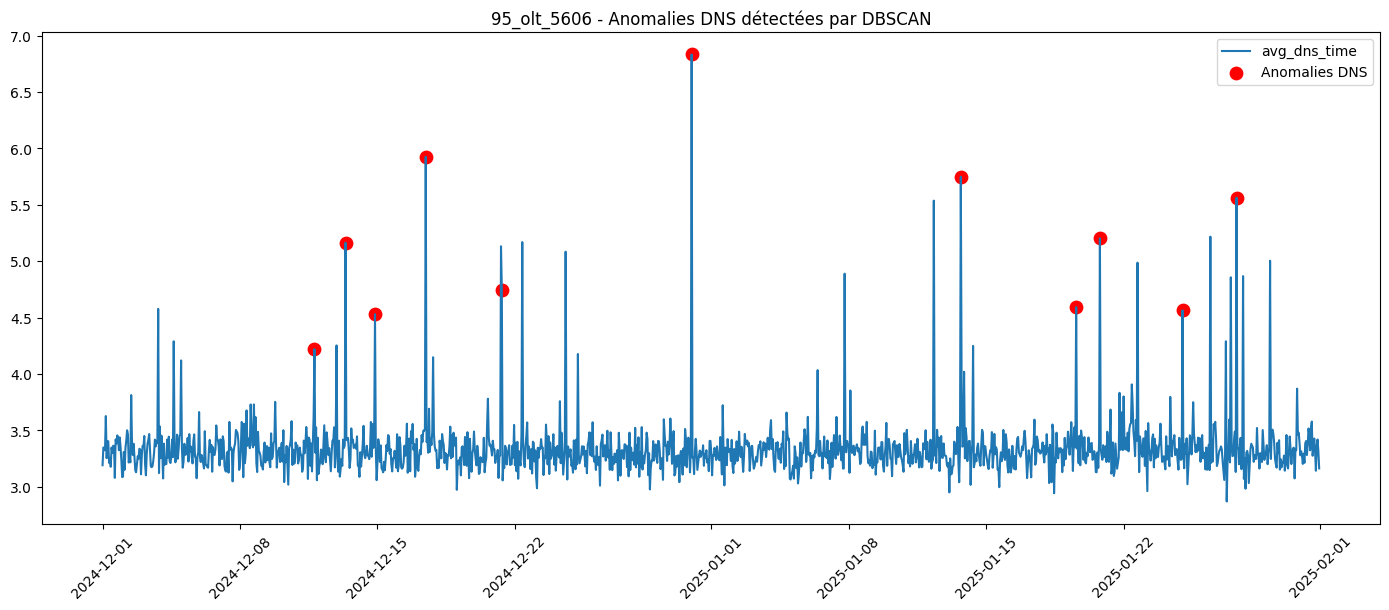

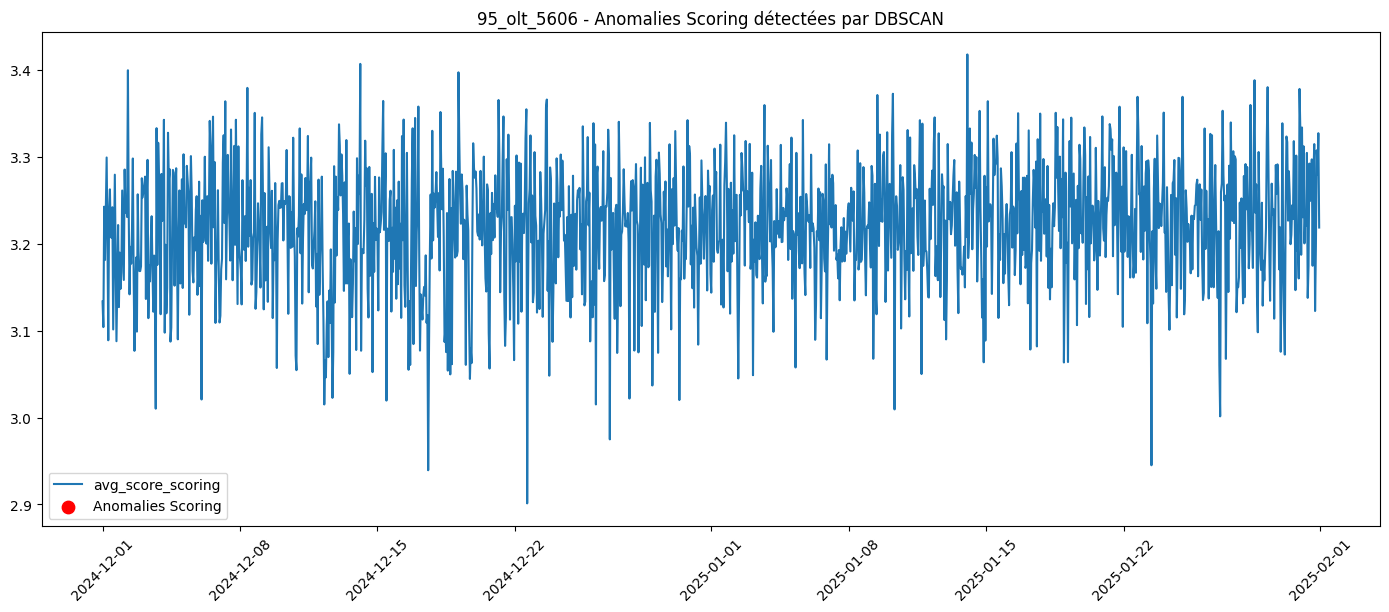

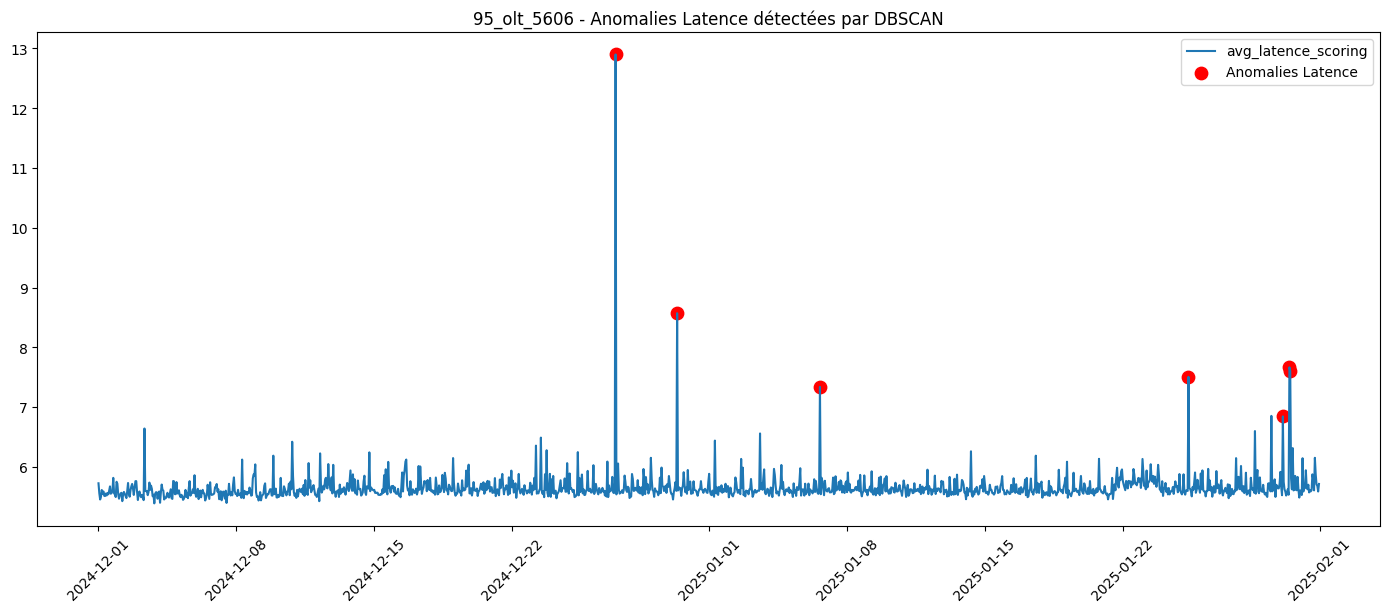

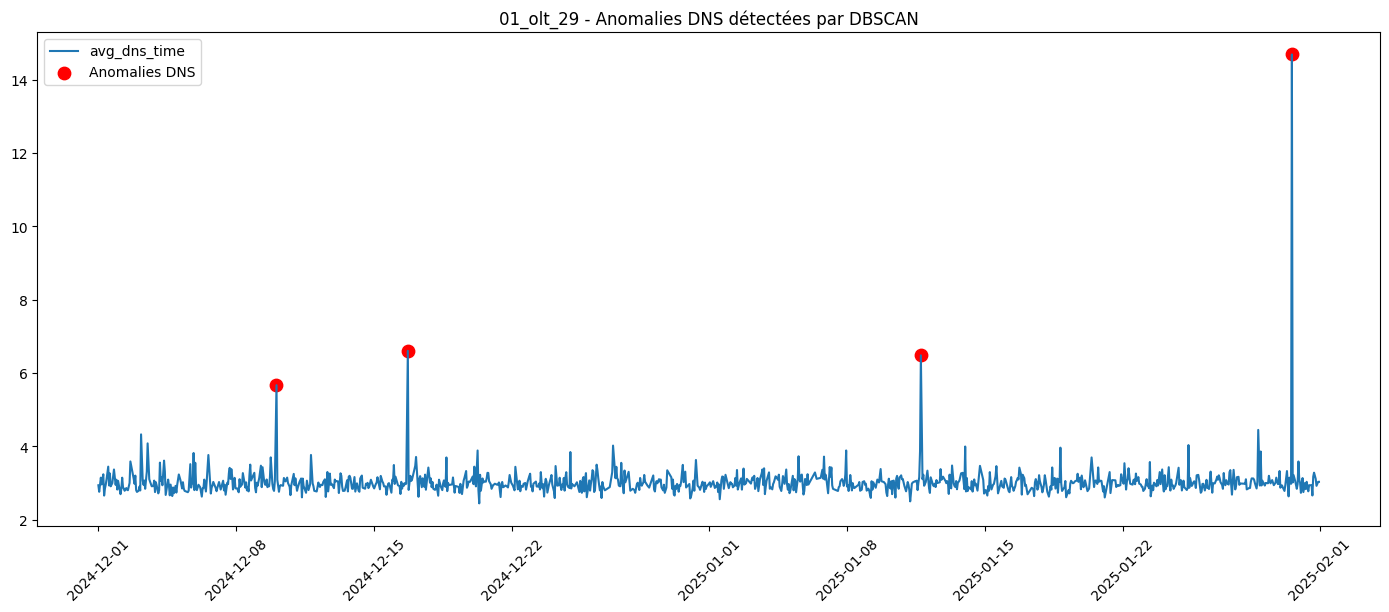

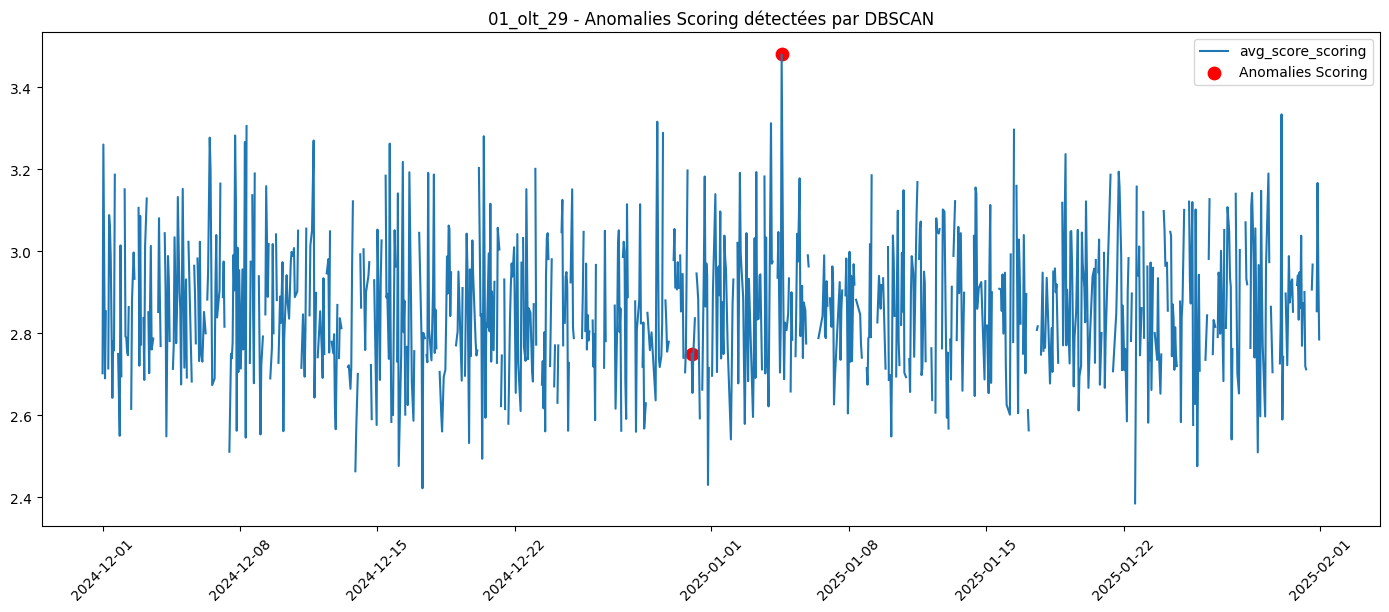

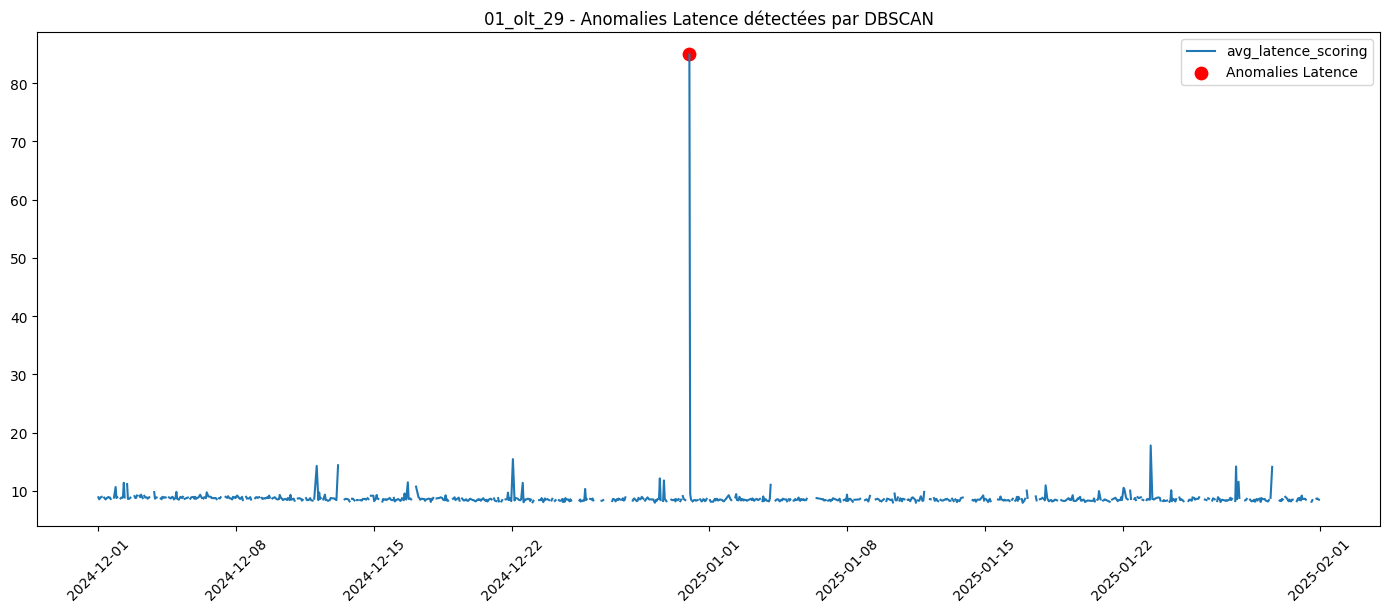

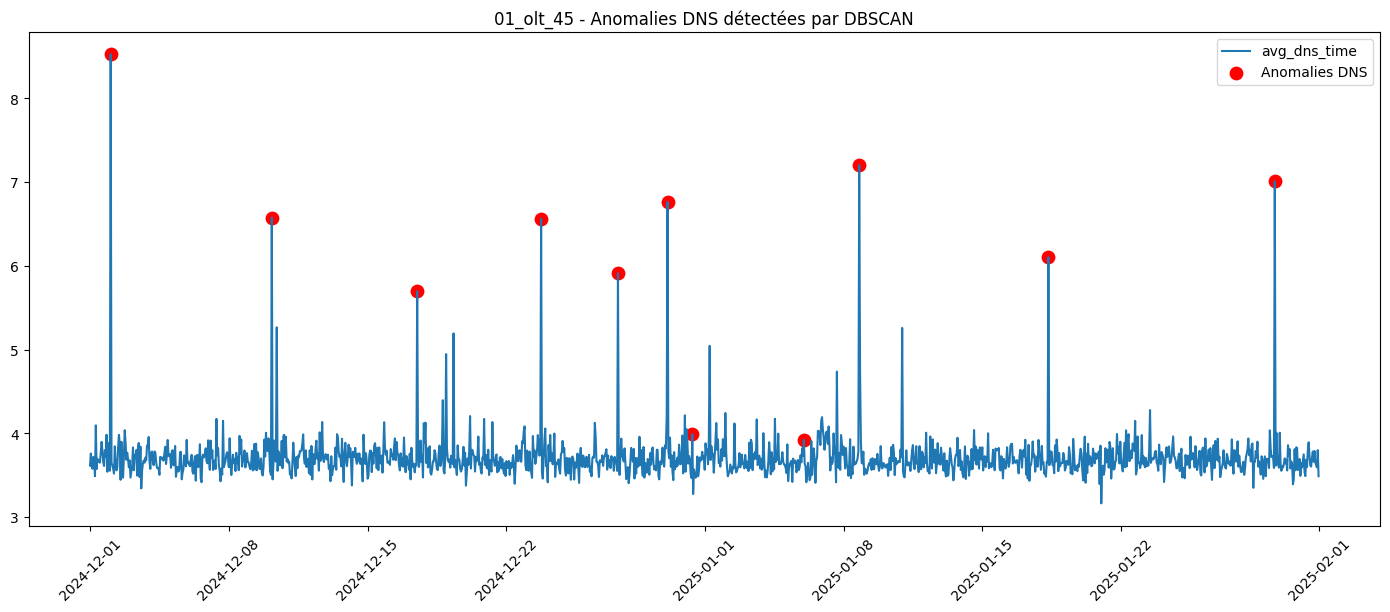

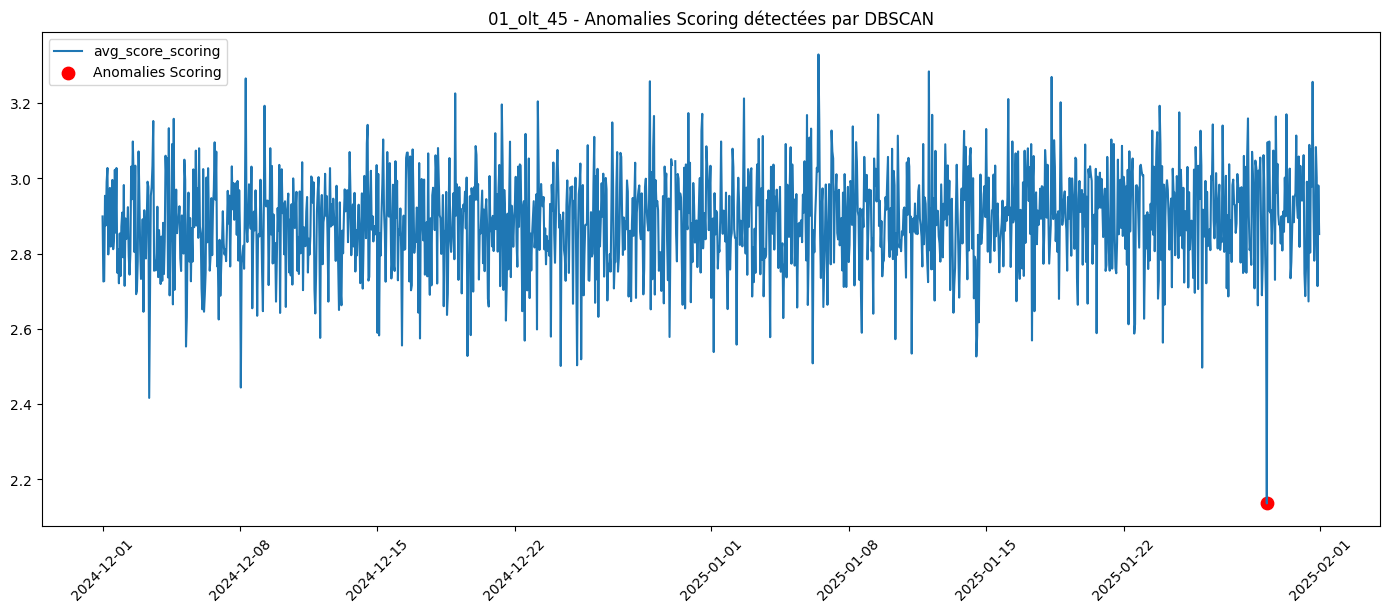

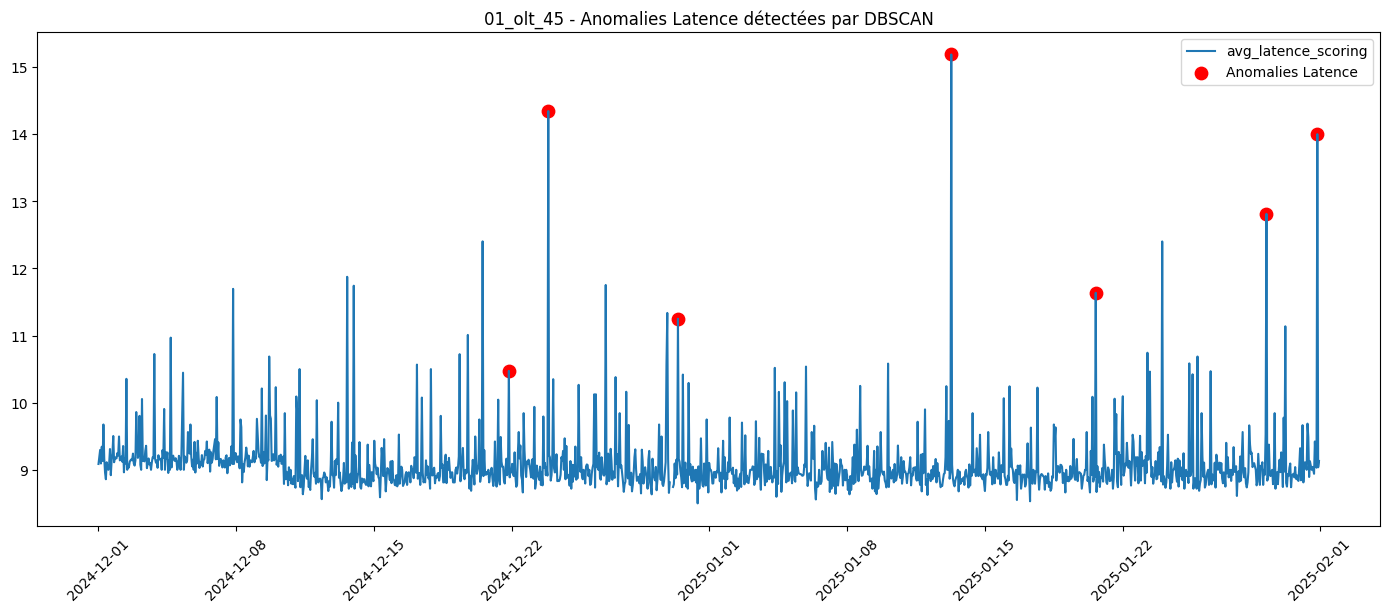

In [16]:
# Visualiser les anomalies pour chaque OLT
for olt in olts_test:
    df_olt = df_with_anomalies[df_with_anomalies['olt_name'] == olt]

    # Pour le test DNS
    plt.figure(figsize=(14, 6))
    plt.plot(df_olt['date_hour'], df_olt['avg_dns_time'], label='avg_dns_time')
    plt.scatter(
        df_olt['date_hour'][df_olt['is_anomaly_dns']],
        df_olt['avg_dns_time'][df_olt['is_anomaly_dns']],
        color='red', label='Anomalies DNS', s=80
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{olt} - Anomalies DNS détectées par DBSCAN")
    plt.show()

    # Pour le test Scoring
    if 'avg_score_scoring' in df_olt.columns and 'is_anomaly_scoring' in df_olt.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_olt['date_hour'], df_olt['avg_score_scoring'], label='avg_score_scoring')
        plt.scatter(
            df_olt['date_hour'][df_olt['is_anomaly_scoring']],
            df_olt['avg_score_scoring'][df_olt['is_anomaly_scoring']],
            color='red', label='Anomalies Scoring', s=80
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{olt} - Anomalies Scoring détectées par DBSCAN")
        plt.show()

    # Pour le test Latence
    if 'avg_latence_scoring' in df_olt.columns and 'is_anomaly_latence' in df_olt.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_olt['date_hour'], df_olt['avg_latence_scoring'], label='avg_latence_scoring')
        plt.scatter(
            df_olt['date_hour'][df_olt['is_anomaly_latence']],
            df_olt['avg_latence_scoring'][df_olt['is_anomaly_latence']],
            color='red', label='Anomalies Latence', s=80
        )
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.title(f"{olt} - Anomalies Latence détectées par DBSCAN")
        plt.show()

In [17]:
def add_anomaly_flags_silent(base_df, test_types=['dns', 'scoring', 'latence']):
    """
    Ajoute silencieusement des colonnes binaires d'anomalies au DataFrame de base
    """
    result_df = base_df.copy()

    # Initialiser les colonnes d'anomalies à False
    for test_type in test_types:
        result_df[f'is_anomaly_{test_type}'] = False

    # Pour chaque OLT
    for olt in base_df['olt_name'].unique():
        df_olt = base_df[base_df['olt_name'] == olt]

        for test_type in test_types:
            # Appliquer DBSCAN
            df_anomalies = detect_anomalies_dbscan(df_olt, test_type=test_type, eps=3, min_samples=3)

            if df_anomalies is not None:
                if test_type == 'dns':
                    anomaly_col = 'anomaly_dns'
                elif test_type == 'scoring':
                    anomaly_col = 'anomaly_scoring'
                elif test_type == 'latence':
                    anomaly_col = 'anomaly_latence'

                # Identifier les dates/heures des anomalies
                anomaly_indices = df_anomalies[df_anomalies[anomaly_col] == -1].index
                anomaly_dates = df_anomalies.loc[anomaly_indices, 'date_hour'].tolist()

                # Mettre à jour le DataFrame résultat
                mask = (result_df['olt_name'] == olt) & (result_df['date_hour'].isin(anomaly_dates))
                result_df.loc[mask, f'is_anomaly_{test_type}'] = True

    return result_df

In [18]:
data_agrege_with_anomalies = add_anomaly_flags_silent(data_agrege_S3, test_types=['dns', 'scoring', 'latence'])

In [20]:
data_agrege_with_anomalies

,olt_name,date_hour,code_departement,olt_model,peag_nro,boucle,dsp,pop_dns,nb_test_dns,avg_dns_time,...,type_boucle,type_olt_model,encodage_heure_sin,encodage_heure_cos,encodage_jour_semaine_sin,encodage_jour_semaine_cos,week_end,is_anomaly_dns,is_anomaly_scoring,is_anomaly_latence
0,01_olt_1,2024-12-01 00:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,61,4.888439,...,BU,old,0.000000,1.000000e+00,-0.781831,0.623490,True,False,False,False
1,01_olt_1,2024-12-01 01:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,58,5.293034,...,BU,old,0.258819,9.659258e-01,-0.781831,0.623490,True,False,False,False
2,01_olt_1,2024-12-01 02:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,67,5.103739,...,BU,old,0.500000,8.660254e-01,-0.781831,0.623490,True,False,False,False
3,01_olt_1,2024-12-01 03:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,40,5.342719,...,BU,old,0.707107,7.071068e-01,-0.781831,0.623490,True,False,False,False
4,01_olt_1,2024-12-01 04:00:00,01,old0,01_peag_1,BU966,dsp_1,69_lyon,50,4.997415,...,BU,old,0.866025,5.000000e-01,-0.781831,0.623490,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3856687,95_olt_5631,2025-01-30 06:00:00,95,M24,95_peag_2880,BU4,dsp_1,77_mit,24,3.206562,...,BU,New,1.000000,6.123234e-17,0.433884,-0.900969,False,False,False,False
3856688,95_olt_5631,2025-01-30 09:00:00,95,M24,95_peag_2880,BU4,dsp_1,77_mit,24,2.986437,...,BU,New,0.707107,-7.071068e-01,0.433884,-0.900969,False,False,False,False
3856689,95_olt_5631,2025-01-30 17:00:00,95,M24,95_peag_2880,BU4,dsp_1,77_mit,24,3.264313,...,BU,New,-0.965926,-2.588190e-01,0.433884,-0.900969,False,False,False,True
3856690,95_olt_5631,2025-01-31 02:00:00,95,M24,95_peag_2880,BU4,dsp_1,77_mit,12,3.211313,...,BU,New,0.500000,8.660254e-01,-0.433884,-0.900969,False,False,False,False


In [19]:
output_parquet_path = "/content/drive/MyDrive/nexialog/data_with_anomalies_with_DBSCAN_model.parquet"

# Exporter au format Parquet
data_agrege_with_anomalies.to_parquet(output_parquet_path, index=False, engine='pyarrow')
print(f"Fichier Parquet exporté avec succès à : {output_parquet_path}")

Fichier Parquet exporté avec succès à : /content/drive/MyDrive/nexialog/data_with_anomalies_with_DBSCAN_model.parquet
